In [1]:
import numpy as np 
import pandas as pd

In [2]:
df=pd.read_csv("df_test.csv")

In [3]:
df.shape

(6700, 14)

In [4]:
df.columns

Index(['date', 'price', 'bedrooms', 'grade', 'has_basement', 'living_in_m2',
       'renovated', 'nice_view', 'perfect_condition', 'real_bathrooms',
       'has_lavatory', 'single_floor', 'month', 'quartile_zone'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6700 entries, 0 to 6699
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               6700 non-null   object 
 1   price              6700 non-null   float64
 2   bedrooms           6700 non-null   int64  
 3   grade              6700 non-null   int64  
 4   has_basement       6700 non-null   bool   
 5   living_in_m2       6700 non-null   float64
 6   renovated          6700 non-null   bool   
 7   nice_view          6700 non-null   bool   
 8   perfect_condition  6700 non-null   bool   
 9   real_bathrooms     6700 non-null   int64  
 10  has_lavatory       6700 non-null   bool   
 11  single_floor       6700 non-null   bool   
 12  month              6700 non-null   int64  
 13  quartile_zone      6700 non-null   int64  
dtypes: bool(6), float64(2), int64(5), object(1)
memory usage: 458.1+ KB


In [6]:
df.isna().sum()

date                 0
price                0
bedrooms             0
grade                0
has_basement         0
living_in_m2         0
renovated            0
nice_view            0
perfect_condition    0
real_bathrooms       0
has_lavatory         0
single_floor         0
month                0
quartile_zone        0
dtype: int64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

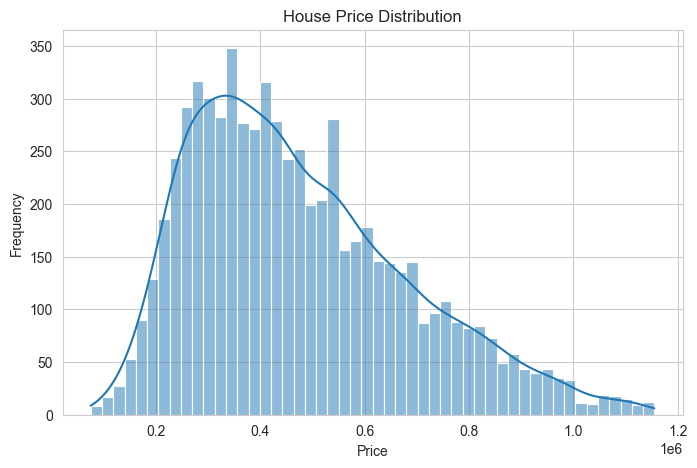

In [8]:
plt.figure()

sns.histplot(df["price"], bins=50, kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

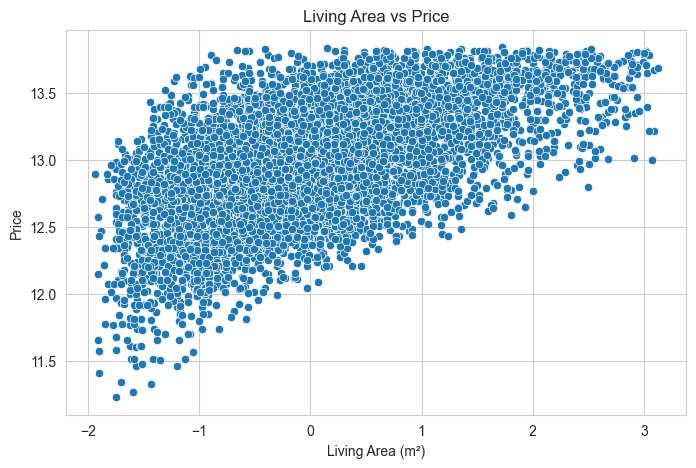

In [26]:
plt.figure()

sns.scatterplot(
    x=df["living_in_m2"],
    y=df["price"]
)

plt.title("Living Area vs Price")
plt.xlabel("Living Area (m²)")
plt.ylabel("Price")

plt.show()

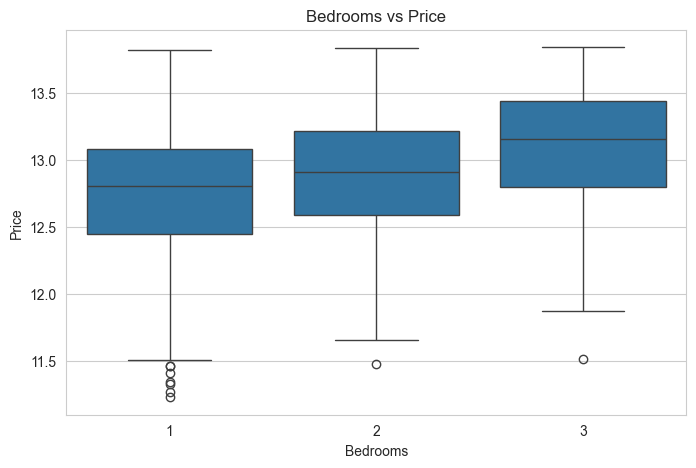

In [27]:
plt.figure()

sns.boxplot(
    x=df["bedrooms"],
    y=df["price"]
)

plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

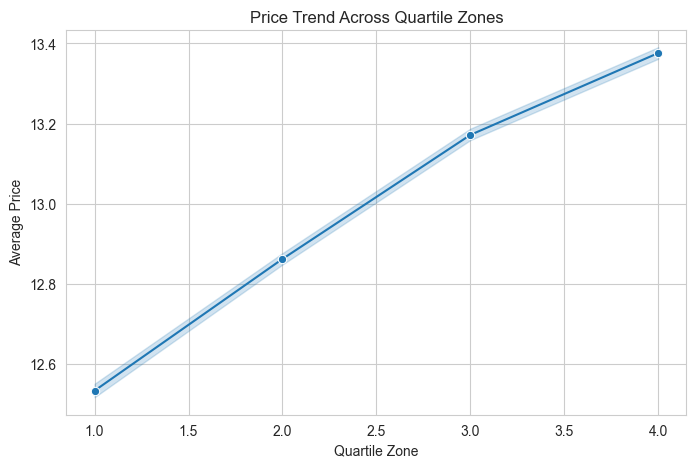

In [38]:
plt.figure()

sns.lineplot(
    x="quartile_zone",
    y="price",
    data=df,
    estimator="mean",
    marker="o"
)

plt.title("Price Trend Across Quartile Zones")
plt.xlabel("Quartile Zone")
plt.ylabel("Average Price")

plt.show()

In [9]:
df["year"] = pd.to_datetime(df["date"]).dt.year

In [10]:
df.drop(columns=['date','has_basement','has_lavatory','month'],inplace=True)

In [11]:
df.head()

,price,bedrooms,grade,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,single_floor,quartile_zone,year
0,305000.0,2,1,76.18046,False,False,True,1,True,2,2014
1,498000.0,3,2,210.88981,False,False,False,2,True,2,2014
2,590000.0,2,4,262.91549,False,False,False,2,False,2,2015
3,775000.0,3,3,159.79316,False,False,False,1,False,3,2014
4,350000.0,2,1,92.90300,False,False,False,1,True,3,2015


In [12]:
df.shape

(6700, 11)

In [13]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
LE=LabelEncoder()
cols=df.columns
for i in cols:
    if df[i].dtype=='bool':
        df[i]=LE.fit_transform(df[i])



In [14]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

print("Number of outliers:", len(outliers))
print((len(outliers) / len(df)) * 100)

Number of outliers: 82
1.2238805970149254


In [15]:
df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

In [16]:
SS=StandardScaler()
df[['living_in_m2']] = SS.fit_transform(df[['living_in_m2']])

df['price']=np.log(df['price'])

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split as tts

In [18]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [19]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)

In [20]:
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [21]:
y_pd_logged=lr.predict(x_test)
y_pd=np.exp(y_pd_logged)

In [22]:
y_test=np.exp(y_test)

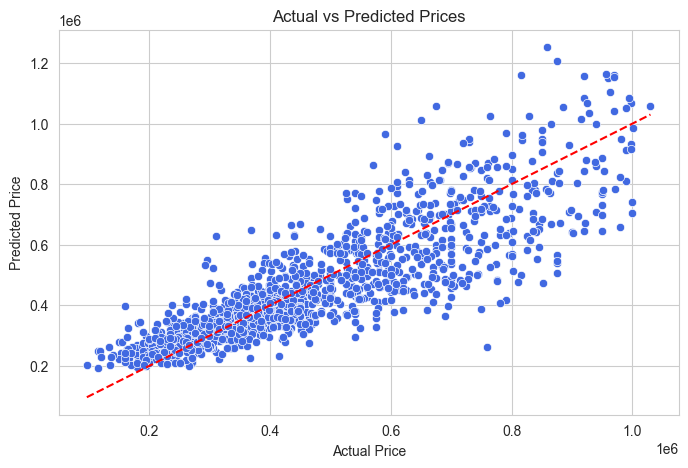

In [37]:
plt.figure()

sns.scatterplot(
    x=y_test,
    y=y_pd,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

In [23]:
from sklearn.metrics import r2_score
sc=r2_score(y_test,y_pd)
sc

0.725299169929752

In [24]:
# import joblib,os
# def save_model(self, path="house_price_model.pkl"):
#     if os.path.exists(path):
#         choice = input("Model already exists. Do you want to replace it? (y/n): ").strip().lower()
#         if choice != "y":
#             print("Model was not replaced.")
#             return

#     joblib.dump(self.model, path)
#     print("Model saved successfully.")